# Day45_Feature_Selection 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read the data

# 45.1.1 Univariate feature selection – 

## 45.1.1.1 Classfication

In [10]:
cls_df=pd.read_csv('pima_indians_diabetes.csv')
cls_df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
cx = cls_df.iloc[:,:8]
cy = cls_df.iloc[:,8]

In [14]:
cx.columns

Index(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age'], dtype='object')

- Build the feature selectin model - Univariate feature selection.

In [16]:
from sklearn.feature_selection import SelectKBest,chi2,f_regression

In [18]:
clf_model=SelectKBest(k=4,score_func=chi2)

In [20]:
selected_features=clf_model.fit_transform(cx,cy)
selected_features

array([[148. ,   0. ,  33.6,  50. ],
       [ 85. ,   0. ,  26.6,  31. ],
       [183. ,   0. ,  23.3,  32. ],
       ...,
       [121. , 112. ,  26.2,  30. ],
       [126. ,   0. ,  30.1,  47. ],
       [ 93. ,   0. ,  30.4,  23. ]])

- find out the selected 4 columns

In [37]:
clf_model.get_support()

array([False,  True, False, False,  True,  True, False,  True])

In [43]:
clf_model.get_feature_names_out()

array(['plas', 'test', 'mass', 'age'], dtype=object)

In [57]:
clf_model.scores_

array([ 111.51969064, 1411.88704064,   17.60537322,   53.10803984,
       2175.56527292,  127.66934333,    5.39268155,  181.30368904])

In [65]:
clf_model.head()

AttributeError: 'SelectKBest' object has no attribute 'head'

In [71]:
feat_imp=pd.DataFrame()
feat_imp['features']=cx.columns
feat_imp['importances']=clf_model.scores_
feat_imp.head(8)

,features,importances
0,preg,111.519691
1,plas,1411.887041
2,pres,17.605373
3,skin,53.108040
4,test,2175.565273
5,mass,127.669343
6,pedi,5.392682
7,age,181.303689


In [73]:
feat_imp.sort_values(by='importances',ascending=False)

,features,importances
4,test,2175.565273
1,plas,1411.887041
7,age,181.303689
5,mass,127.669343
0,preg,111.519691
3,skin,53.108040
2,pres,17.605373
6,pedi,5.392682


<Figure size 400x300 with 0 Axes>

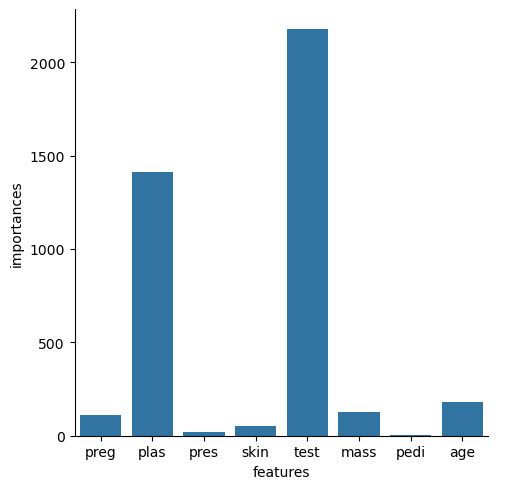

In [79]:
plt.figure(figsize=(4,3))
sns.catplot(feat_imp,x='features',y='importances',kind='bar')
plt.show()

In [51]:
clf_selected_model=pd.DataFrame(selected_features,columns=clf_model.get_feature_names_out())
clf_selected_model.head()

,plas,test,mass,age
0,148.0,0.0,33.6,50.0
1,85.0,0.0,26.6,31.0
2,183.0,0.0,23.3,32.0
3,89.0,94.0,28.1,21.0
4,137.0,168.0,43.1,33.0


In [55]:
clf_selected_model['class']=cy
clf_selected_model.head()

,plas,test,mass,age,class
0,148.0,0.0,33.6,50.0,1
1,85.0,0.0,26.6,31.0,0
2,183.0,0.0,23.3,32.0,1
3,89.0,94.0,28.1,21.0,0
4,137.0,168.0,43.1,33.0,1


## 45.1.1.2 Regression

In [86]:
reg_df=pd.read_csv('kc_house_data.csv')
reg_df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,1955.0,0.0,98178.0,47.5112,-122.257,1340.0,5650.0
1,538000.0,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,98125.0,47.7210,-122.319,1690.0,7639.0
2,180000.0,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,1933.0,0.0,98028.0,47.7379,-122.233,2720.0,8062.0
3,604000.0,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,1965.0,0.0,98136.0,47.5208,-122.393,1360.0,5000.0
4,510000.0,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,1987.0,0.0,98074.0,47.6168,-122.045,1800.0,7503.0


In [108]:
reg_df.dropna(inplace=True)

In [110]:
rx=reg_df.iloc[:,1:19]
ry=reg_df.iloc[:,0]


In [104]:
print(ry)

0        221900.0
1        538000.0
2        180000.0
3        604000.0
4        510000.0
           ...   
21608    360000.0
21609    400000.0
21610    402101.0
21611    400000.0
21612    325000.0
Name: price, Length: 21613, dtype: float64


In [88]:
reg_featsel_model=SelectKBest(k=5,score_func=f_regression)

In [112]:
reg_featsel_model_final=reg_featsel_model.fit_transform(rx,ry)

In [118]:
reg_featsel_model_final

array([[1.00e+00, 1.18e+03, 7.00e+00, 1.18e+03, 1.34e+03],
       [2.25e+00, 2.57e+03, 7.00e+00, 2.17e+03, 1.69e+03],
       [1.00e+00, 7.70e+02, 6.00e+00, 7.70e+02, 2.72e+03],
       ...,
       [7.50e-01, 1.02e+03, 7.00e+00, 1.02e+03, 1.02e+03],
       [2.50e+00, 1.60e+03, 8.00e+00, 1.60e+03, 1.41e+03],
       [7.50e-01, 1.02e+03, 7.00e+00, 1.02e+03, 1.02e+03]])

In [120]:
reg_featsel_model.get_support()

array([False,  True,  True, False, False, False, False, False,  True,
        True, False, False, False, False, False, False,  True, False])

In [124]:
reg_featsel_model.get_feature_names_out()

array(['bathrooms', 'sqft_living', 'grade', 'sqft_above', 'sqft_living15'],
      dtype=object)

In [126]:
reg_featsel_model.scores_

array([ 342.58935788,  980.48387854, 2232.61288362,   59.01822824,
          6.03139181,  156.73290625,  428.32356231,    4.78749835,
       2273.07607421, 1380.76105131,  352.87097595,   23.40541039,
          7.98135333,   50.63053854,  221.32003725,   26.7075084 ,
        795.21100851,   55.67220886])

In [136]:
imporatnces_df=pd.DataFrame()
imporatnces_df['features']=rx.columns
imporatnces_df['score']=reg_featsel_model.scores_
imporatnces_df

,features,score
0,bedrooms,342.589358
1,bathrooms,980.483879
2,sqft_living,2232.612884
3,sqft_lot,59.018228
4,floors,6.031392
5,waterfront,156.732906
6,view,428.323562
7,condition,4.787498
8,grade,2273.076074
9,sqft_above,1380.761051


In [138]:
imporatnces_df.sort_values(by='score',ascending=False)

,features,score
8,grade,2273.076074
2,sqft_living,2232.612884
9,sqft_above,1380.761051
1,bathrooms,980.483879
16,sqft_living15,795.211009
6,view,428.323562
10,sqft_basement,352.870976
0,bedrooms,342.589358
14,lat,221.320037
5,waterfront,156.732906


# 45.1.2 Recursive feature elimination – 

## 45.1.2.1 Classfication

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

In [157]:
clf_rfe=RFE(estimator=LogisticRegression(max_iter=400),n_features_to_select=4)
clf_rfe.fit_transform(cx,cy)

array([[  6.   , 148.   ,  33.6  ,   0.627],
       [  1.   ,  85.   ,  26.6  ,   0.351],
       [  8.   , 183.   ,  23.3  ,   0.672],
       ...,
       [  5.   , 121.   ,  26.2  ,   0.245],
       [  1.   , 126.   ,  30.1  ,   0.349],
       [  1.   ,  93.   ,  30.4  ,   0.315]])

In [161]:
clf_rfe.ranking_

array([1, 1, 3, 5, 4, 1, 1, 2])

In [163]:
cx.columns

Index(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age'], dtype='object')

In [167]:
final_model3=pd.DataFrame()
final_model3['feature']=cx.columns
final_model3['rank']=clf_rfe.ranking_

In [169]:
final_model3

,feature,rank
0,preg,1
1,plas,1
2,pres,3
3,skin,5
4,test,4
5,mass,1
6,pedi,1
7,age,2


In [171]:
final_model3.sort_values(by='rank')

,feature,rank
0,preg,1
1,plas,1
5,mass,1
6,pedi,1
7,age,2
2,pres,3
4,test,4
3,skin,5


## 45.1.2.2 Regression

In [22]:
from sklearn.linear_model import LinearRegression
from  sklearn.feature_selection import RFE

In [24]:
reg_rfe=RFE(estimator=LinearRegression(),n_features_to_select=6)

In [26]:
reg_rfe.fit_transform(rx,ry)

NameError: name 'rx' is not defined

In [182]:
reg_rfe.ranking_

array([ 2,  1,  7, 13,  1,  1,  1,  3,  1,  8,  9,  5, 10,  6,  1,  4, 11,
       12])

In [186]:
rx.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [188]:
rfe_reg_final_model=pd.DataFrame()
rfe_reg_final_model['features']=rx.columns
rfe_reg_final_model['rank']=reg_rfe.ranking_
rfe_reg_final_model

,features,rank
0,bedrooms,2
1,bathrooms,1
2,sqft_living,7
3,sqft_lot,13
4,floors,1
5,waterfront,1
6,view,1
7,condition,3
8,grade,1
9,sqft_above,8


In [190]:
rfe_reg_final_model.sort_values(by='rank')

,features,rank
8,grade,1
1,bathrooms,1
14,lat,1
6,view,1
4,floors,1
5,waterfront,1
0,bedrooms,2
7,condition,3
15,long,4
11,yr_built,5


# 45.1.3 Decision Tree – 

## 45.1.3.1 Regression

In [28]:
from sklearn.tree import DecisionTreeRegressor

In [30]:
rtree = DecisionTreeRegressor(max_depth=8)
rtree.fit(rx,ry)

NameError: name 'rx' is not defined

In [198]:
rtree.feature_importances_

array([3.99593499e-04, 1.02955920e-02, 4.99093543e-01, 7.91718965e-03,
       1.19274993e-04, 0.00000000e+00, 7.33063228e-02, 3.49525708e-05,
       1.74725067e-01, 6.90496750e-03, 7.31419778e-03, 2.74465474e-03,
       0.00000000e+00, 3.17525354e-02, 1.02773930e-01, 5.47857331e-02,
       2.14171266e-02, 6.41531841e-03])

In [200]:
feat_imp = pd.DataFrame()
feat_imp['feature'] = rx.columns
feat_imp['importance'] = rtree.feature_importances_
feat_imp

,feature,importance
0,bedrooms,0.000400
1,bathrooms,0.010296
2,sqft_living,0.499094
3,sqft_lot,0.007917
4,floors,0.000119
5,waterfront,0.000000
6,view,0.073306
7,condition,0.000035
8,grade,0.174725
9,sqft_above,0.006905


In [204]:
feat_imp.sort_values(by='importance',ascending=False)

,feature,importance
2,sqft_living,0.499094
8,grade,0.174725
14,lat,0.102774
6,view,0.073306
15,long,0.054786
13,zipcode,0.031753
16,sqft_living15,0.021417
1,bathrooms,0.010296
3,sqft_lot,0.007917
10,sqft_basement,0.007314


## 45.1.3.1 Classification

In [2]:
from sklearn.tree import DecisionTreeClassifier

In [32]:
ctree =  DecisionTreeClassifier(max_depth=6)
ctree.fit(cx,cy)

DecisionTreeClassifier(max_depth=6)

In [34]:
ctree.feature_importances_

array([0.02425246, 0.42909372, 0.06652782, 0.        , 0.02194844,
       0.23015291, 0.09535546, 0.1326692 ])

In [36]:
feat_imp = pd.DataFrame()
feat_imp['feature'] = cx.columns
feat_imp['importance'] = ctree.feature_importances_
feat_imp

,feature,importance
0,preg,0.024252
1,plas,0.429094
2,pres,0.066528
3,skin,0.000000
4,test,0.021948
5,mass,0.230153
6,pedi,0.095355
7,age,0.132669
